# 반도체 공정 스케줄링 시뮬레이션 결과

## 환경 설정

In [281]:
import os
import simpy
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Noto Sans KR'

# .env 파일의 환경 변수 로드
load_dotenv()

# .env 파일의 파라미터
BASE_DATA_PATH = os.getenv('BASE_DATA_PATH', 'data')
SIM_TIME = 120

## 모듈 import

In [282]:
from utils import DataLoader, EventLogger
from utils.visualizer import create_gantt_chart
from simulation import Job
from algorithms.stage1 import RuleBasedDispatch, RuleBasedStage1Scheduler
from algorithms.stage2.rule_based_pm import Stage2RuleBasedPMScheduler
from connectors.schedule_io import save_event_log, save_schedule_summary


## 데이터 로드

In [283]:
data_loader = DataLoader(BASE_DATA_PATH)

data = data_loader.load_all_data()

print("=" * 60)
print("데이터 개요")
print("=" * 60)
print(f"Jobs: {len(data['jobs'])} 개")
print(f"Operations: {len(data['operations'])} 개")
print(f"Machines: {len(data['machines'])} 개")
print(f"Machine Failures: {len(data['machine_failure'])} 개")
print(f"Setup Times: {len(data['setup_times'])} 개")
print(f"Operation-Machine Map: {len(data['operation_machine_map'])} 개")

데이터 개요
Jobs: 10 개
Operations: 35 개
Machines: 8 개
Machine Failures: 8 개
Setup Times: 12 개
Operation-Machine Map: 95 개


## 시뮬레이션 실행

In [284]:
# SimPy 환경 생성
env = simpy.Environment()

# 이벤트 로거 생성
event_logger = EventLogger(env)

# Stage I 알고리즘 — 복합 Dispatching Rule
algorithm = RuleBasedDispatch()

# Stage I 스케줄러 (고장/수리 비활성화)
scheduler = RuleBasedStage1Scheduler(
    env=env,
    machine_df=data['machines'],
    operations_df=data['operations'],
    machine_failure_df=data['machine_failure'],
    setup_times_df=data['setup_times'],
    op_machine_df=data['operation_machine_map'],
    jobs_df=data['jobs'],
    qtime_constraints_df=data['qtime_constraints'],
    event_logger=event_logger,
    algorithm=algorithm,
)

## 작업 생성

In [285]:
jobs = []
for _, job_info in data['jobs'].iterrows():
    job_id = job_info['job_id']
    op_info = data['operations'][data['operations']['job_id'] == job_id].sort_values('op_seq')
    qtime_df = data_loader.get_qtime_for_job(data['qtime_constraints'], job_id)
    job = Job(
        env=env,
        job_info=job_info.to_dict(),
        op_info=op_info,
        qtime_df=qtime_df,
        scheduler=scheduler,
        event_logger=event_logger,
    )
    jobs.append(job)

## 시뮬레이션 실행

In [286]:
env.run(until=env.all_of(job.process for job in jobs))

fig = create_gantt_chart(
    logs=event_logger.logs,
    max_time=env.now,
    title=f'Stage I Rule-Based Gantt Chart (Simulation Time: {round(env.now, 3)})',
)
fig.show()

## Stage II 시뮬레이션 실행

In [287]:
# SimPy 환경 생성
env_stage2 = simpy.Environment()

# 이벤트 로거 생성
event_logger_stage2 = EventLogger(env_stage2)

# Stage II 알고리즘
algorithm_stage2 = RuleBasedDispatch()

scheduler_stage2 = Stage2RuleBasedPMScheduler(
    env=env_stage2,
    machine_df=data['machines'],
    operations_df=data['operations'],
    machine_failure_df=data['machine_failure'],
    setup_times_df=data['setup_times'],
    op_machine_df=data['operation_machine_map'],
    jobs_df=data['jobs'],
    qtime_constraints_df=data['qtime_constraints'],
    event_logger=event_logger_stage2,
    algorithm=algorithm_stage2,
    pm_threshold=0.5,
)

## Stage II 작업생성

In [288]:
jobs_stage2 = []
for _, job_info in data['jobs'].iterrows():
    job_id = job_info['job_id']
    op_info = data['operations'][data['operations']['job_id'] == job_id].sort_values('op_seq')
    qtime_df = data_loader.get_qtime_for_job(data['qtime_constraints'], job_id)
    job = Job(
        env=env_stage2,
        job_info=job_info.to_dict(),
        op_info=op_info,
        qtime_df=qtime_df,
        scheduler=scheduler_stage2,
        event_logger=event_logger_stage2,
    )
    jobs_stage2.append(job)



In [289]:
env_stage2.run(until=env_stage2.all_of(job.process for job in jobs_stage2))

# ── Stage II 간트 차트 시각화 ──────────────────────────────────────────────────
fig_stage2 = create_gantt_chart(
    logs=event_logger_stage2.logs,
    max_time=env_stage2.now,
    title=f'Stage II Dynamic PM Gantt Chart (Simulation Time: {round(env_stage2.now, 3)})',
)
fig_stage2.show()

## 시뮬레이션 KPI 및 통계

> Stage I (고장 없음, Rule-Based) 과 Stage II (고장 있음, 동적 PM) 결과를 나란히 비교합니다.

### 작업별 통계

In [290]:
df_logs    = pd.DataFrame(event_logger.logs)
df_logs_s2 = pd.DataFrame(event_logger_stage2.logs)

# Stage I
completed_s1  = [j for j in jobs if j.is_completed]
qtime_viol_s1 = sum(j.total_qtime_over for j in jobs)
makespan_s1   = max((j.completed_time for j in completed_s1), default=0)

# Stage II
completed_s2  = [j for j in jobs_stage2 if j.is_completed]
qtime_viol_s2 = sum(j.total_qtime_over for j in jobs_stage2)
makespan_s2   = max((j.completed_time for j in completed_s2), default=0)

sep = "=" * 72
sep2 = "-" * 72
print(sep)
print(f"{'':10} {'Stage I (고장 없음)':>22}   {'Stage II (동적 PM)':>22}")
print(f"{'Job ID':<10} {'QTime 위반':>12} {'완료':>8}   {'QTime 위반':>12} {'완료':>8}")
print(sep2)
for j1, j2 in zip(jobs, jobs_stage2):
    print(f"{j1.id:<10} {round(j1.total_qtime_over,2):>12} {str(j1.is_completed):>8}   {round(j2.total_qtime_over,2):>12} {str(j2.is_completed):>8}")
print(sep2)
print(f"{'총 작업 수':<10} {len(jobs):>12}           {len(jobs_stage2):>12}")
print(f"{'완료 수':<10} {len(completed_s1):>12}           {len(completed_s2):>12}")
print(f"{'Makespan':<10} {round(makespan_s1,2):>12}           {round(makespan_s2,2):>12}")
print(f"{'QTime 위반':<10} {round(qtime_viol_s1,2):>12}           {round(qtime_viol_s2,2):>12}")


                  Stage I (고장 없음)         Stage II (동적 PM)
Job ID         QTime 위반       완료       QTime 위반       완료
------------------------------------------------------------------------
J1                  0.0     True            0.0     True
J2                  2.0     True            2.0     True
J3                  0.0     True            0.0    False
J4                  0.0     True            0.0     True
J5                  9.0     True            9.0     True
J6                 16.0     True           16.0     True
J7                 31.0     True            0.0    False
J8                 14.0     True            0.0     True
J9                 12.0     True          15.63    False
J10                16.0     True            0.0     True
------------------------------------------------------------------------
총 작업 수               10                     10
완료 수                 10                      7
Makespan            139                  111.1
QTime 위반          100.0    

findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
C:\Users\hun99\AppData\Local\Temp\ipykernel_19164\3814784831.py:32: UserWarning: Glyph 51089 (\N{HANGUL SYLLABLE JAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hun99\AppData\Local\Temp\ipykernel_19164\3814784831.py:32: UserWarning: Glyph 50629 (\N{HANGUL SYLLABLE EOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hun99\AppData\Local\Temp\ipykernel_19164\3814784831.py:32: UserWarn

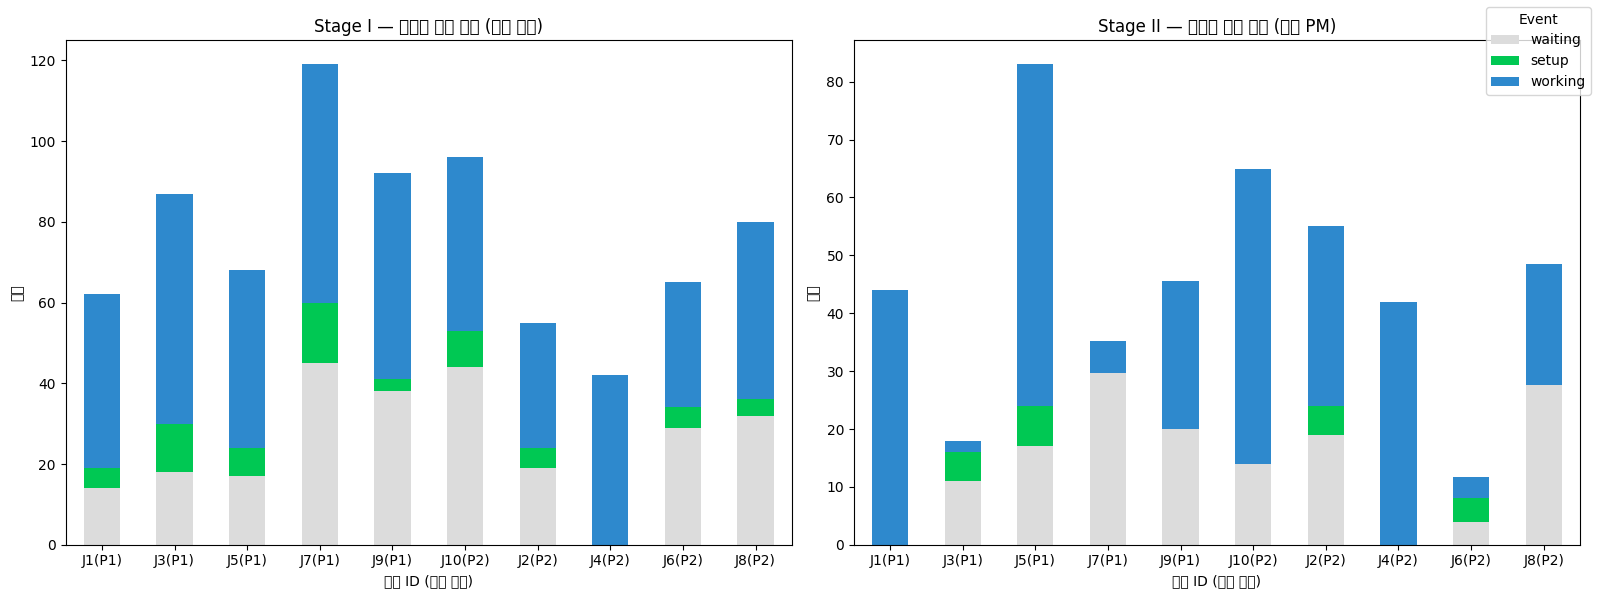

[Stage I]


,waiting,setup,working,job_type
id,,,,
J1,14,5,43,P1
J3,18,12,57,P1
J5,17,7,44,P1
J7,45,15,59,P1
J9,38,3,51,P1
J10,44,9,43,P2
J2,19,5,31,P2
J4,0,0,42,P2
J6,29,5,31,P2


[Stage II]


,waiting,setup,working,job_type
id,,,,
J1,0.000,0.0,44.000,P1
J3,11.000,5.0,1.872,P1
J5,17.000,7.0,59.000,P1
J7,29.641,0.0,5.495,P1
J9,20.000,0.0,25.513,P1
J10,14.000,0.0,51.000,P2
J2,19.000,5.0,31.000,P2
J4,0.000,0.0,42.000,P2
J6,4.000,4.0,3.641,P2


In [276]:
def make_job_stacked(df_logs, jobs_list, env_now, data):
    job_info = df_logs[df_logs['resource'] == 'job'].copy()
    job_info['duration'] = round(job_info['finish'] - job_info['start'], 3)
    job_info = job_info.groupby(['id', 'event'])['duration'].sum().reset_index()
    stacked = job_info.pivot(index='id', columns='event', values='duration').fillna(0)
    stacked = stacked.reindex(columns=['waiting', 'setup', 'working'], fill_value=0)
    job_type_map = data['jobs'].set_index('job_id')['job_type']
    stacked = stacked.join(job_type_map).sort_values('job_type')
    return stacked

stacked_s1 = make_job_stacked(df_logs,    jobs,        env.now,       data)
stacked_s2 = make_job_stacked(df_logs_s2, jobs_stage2, env_stage2.now, data)

COLORS = {"waiting": '#DCDCDC', "setup": '#00C853', "working": '#2E89CD'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, stacked, title in [
    (axes[0], stacked_s1, 'Stage I — 작업별 소요 시간 (고장 없음)'),
    (axes[1], stacked_s2, 'Stage II — 작업별 소요 시간 (동적 PM)'),
]:
    plot_data = stacked[['waiting', 'setup', 'working']].copy()
    plot_data.index = [f"{i}({t})" for i, t in zip(stacked.index, stacked['job_type'])    ]
    plot_data.plot(kind='bar', stacked=True, ax=ax, color=COLORS, legend=False)
    ax.set_title(title)
    ax.set_xlabel('작업 ID (작업 유형)')
    ax.set_ylabel('시간')
    ax.tick_params(axis='x', rotation=0)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Event', loc='upper right')
plt.tight_layout()
plt.show()

print("[Stage I]")
display(stacked_s1)
print("[Stage II]")
display(stacked_s2)


### 공정별 설비 활용률

C:\Users\hun99\AppData\Local\Temp\ipykernel_19164\3756846275.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=util, x='group', y='utilization', ax=ax,
C:\Users\hun99\AppData\Local\Temp\ipykernel_19164\3756846275.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=util, x='group', y='utilization', ax=ax,
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
findfont: Font family 'Noto Sans KR' not found.
C:\Users\hun99\AppData\Local\Temp\ipykernel_19164\3756846275.py:37: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(

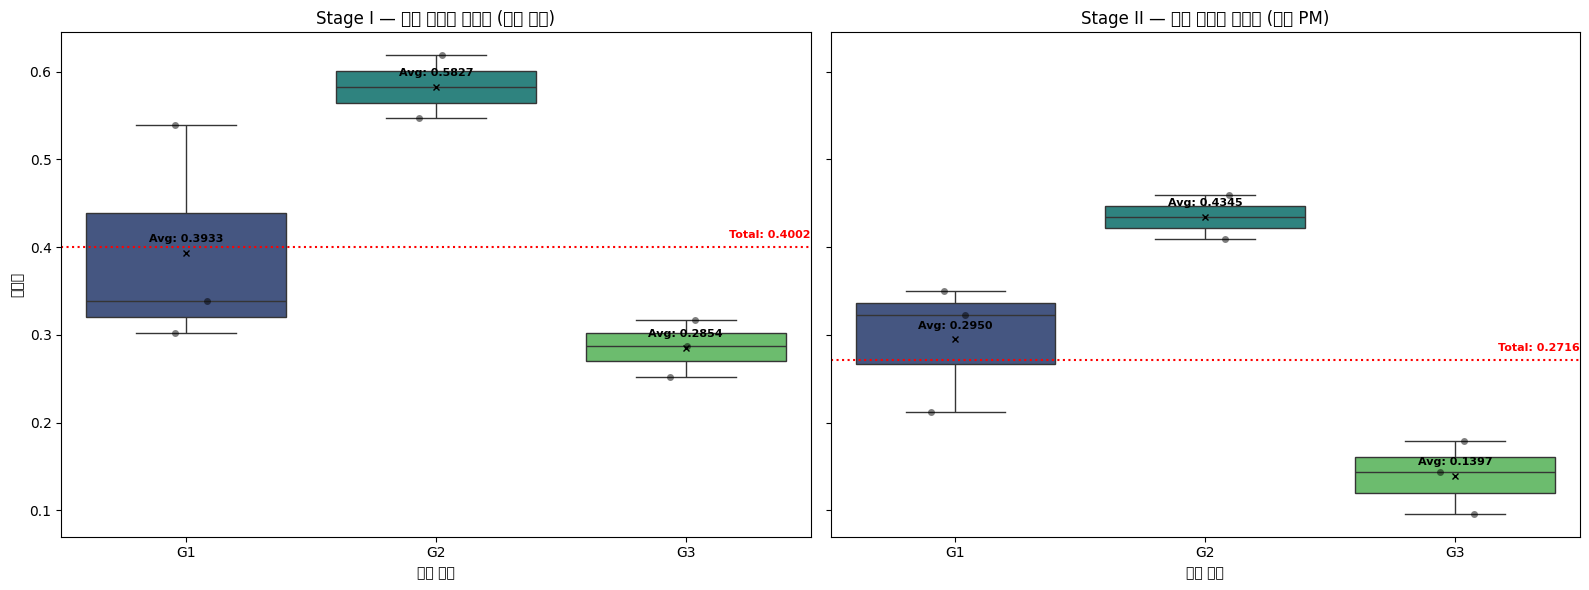

[Stage I 가동률]


,utilization,group
id,,
M1,0.302158,G1
M2,0.539568,G1
M3,0.338129,G1
M4,0.618705,G2
M5,0.546763,G2
M6,0.316547,G3
M7,0.287770,G3
M8,0.251799,G3


[Stage II 가동률]


,utilization,group
id,,
M1,0.211718,G1
M2,0.350356,G1
M3,0.322878,G1
M4,0.459741,G2
M5,0.409203,G2
M6,0.178613,G3
M7,0.096176,G3
M8,0.144264,G3


[Stage I vs Stage II 가동률 비교]


,Stage I,Stage II,차이 (II - I)
id,,,
M1,0.302158,0.211718,-0.0904
M2,0.539568,0.350356,-0.1892
M3,0.338129,0.322878,-0.0153
M4,0.618705,0.459741,-0.1590
M5,0.546763,0.409203,-0.1376
M6,0.316547,0.178613,-0.1379
M7,0.287770,0.096176,-0.1916
M8,0.251799,0.144264,-0.1075


In [265]:
def make_machine_util(df_logs, env_now, data):
    minfo = df_logs[df_logs['resource'] == 'machine'].copy()
    minfo['utilization'] = minfo['finish'] - minfo['start']
    util = pd.DataFrame(
        minfo[minfo['event'] == 'working'].groupby('id')['utilization'].sum() / env_now
    )
    util['group'] = data['machines'].set_index('machine_id').loc[util.index]['machine_group']
    return util

util_s1 = make_machine_util(df_logs,    env.now,        data)
util_s2 = make_machine_util(df_logs_s2, env_stage2.now, data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, util, title in [
    (axes[0], util_s1, 'Stage I — 공정 그룹별 가동률 (고장 없음)'),
    (axes[1], util_s2, 'Stage II — 공정 그룹별 가동률 (동적 PM)'),
]:
    group_means = util.groupby('group')['utilization'].mean()
    total_mean  = util['utilization'].mean()
    sns.boxplot(data=util, x='group', y='utilization', ax=ax,
                palette='viridis', showmeans=True,
                meanprops={'marker':'x', 'markeredgecolor':'black', 'markersize':'5'})
    sns.stripplot(data=util, x='group', y='utilization', ax=ax,
                  color='black', alpha=0.5, jitter=True)
    for i, group in enumerate(group_means.index):
        mv = group_means[group]
        ax.text(i, mv + 0.01, f'Avg: {mv:.4f}',
                ha='center', va='bottom', color='black', fontweight='bold', fontsize=8)
    ax.axhline(total_mean, color='red', linestyle=':')
    ax.text(len(group_means) - 0.5, total_mean + 0.01,
            f'Total: {total_mean:.4f}', color='red', fontweight='bold', ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('공정 그룹')
    ax.set_ylabel('가동률')

plt.tight_layout()
plt.show()

print("[Stage I 가동률]")
display(util_s1)
print("[Stage II 가동률]")
display(util_s2)

# 수치 비교 표
comparison = util_s1[['utilization']].rename(columns={'utilization': 'Stage I'}).join(
    util_s2[['utilization']].rename(columns={'utilization': 'Stage II'})
)
comparison['차이 (II - I)'] = round(comparison['Stage II'] - comparison['Stage I'], 4)
print("[Stage I vs Stage II 가동률 비교]")
display(comparison)
